# 02 - Risk Analysis

# Load Data & Library

Açıklama: Bu bölümde, temizlenmiş e-ticaret veri seti sisteme yüklenir. Analiz sırasında hata oluşmaması için sütun isimleri standart hale getirilir (baş harfleri büyük, boşluklar temizlenmiş). Bu adım, modelin veriyi doğru okumasını sağlar.

In [1]:
# --- REVISI SECTION 1: PASTIKAN SEMUA INI ADA ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Fungsi-fungsi dari Scikit-Learn (Sering terlupakan setelah restart)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

# 1. DETEKSI PATH
current_dir = os.getcwd()
path_file = os.path.join(current_dir, "..", "Data", "Processed", "ecommerce_clean.csv")

try:
    df = pd.read_csv(path_file)
    
    # --- PROSES PEMBERSIHAN NAMA KOLOM (PENTING!) ---
    # Menghapus spasi di depan/belakang dan mengubah huruf pertama jadi Kapital
    # Contoh: ' profit ' atau 'PROFIT' akan menjadi 'Profit'
    df.columns = [col.strip().capitalize() for col in df.columns]
    
    print("Berhasil! Nama kolom yang sekarang terbaca adalah:")
    print(df.columns.tolist())
    display(df.head())
except Exception as e:
    print(f"Gagal memuat data! Error: {e}")

Berhasil! Nama kolom yang sekarang terbaca adalah:
['Order_id', 'Order_date', 'Customer_name', 'Region', 'City', 'Category', 'Sub_category', 'Product_name', 'Quantity', 'Unit_price', 'Discount', 'Sales', 'Profit', 'Payment_mode', 'Month', 'Year', 'Is_trending']


,Order_id,Order_date,Customer_name,Region,City,Category,Sub_category,Product_name,Quantity,Unit_price,Discount,Sales,Profit,Payment_mode,Month,Year,Is_trending
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,10,2024,0
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,8,2025,0
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,11,2023,1
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI,5,2025,1
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card,1,2025,0


# Labeling (Feature Engineering)

Açıklama: Ham veride doğrudan bir "risk" sütunu bulunmadığı için, kâr marjı (Profit/Sales) üzerinden bir hedef değişken oluşturulur. En düşük %15'lik kâr dilimine sahip işlemler "Yüksek Risk" (1) olarak etiketlenir. Bu, makine öğrenmesi modelinin neyi tahmin edeceğini belirler.

In [2]:
# --- SECTION 2: LABELING ---

try:
    # 1. Hitung Margin (Profit / Sales * 100)
    # Karena sudah di-capitalize di Section 1, namanya PASTI 'Profit' dan 'Sales'
    df['Margin_Pct'] = (df['Profit'] / df['Sales']) * 100

    # 2. Tentukan ambang batas risiko (15% margin terendah)
    threshold = df['Margin_Pct'].quantile(0.15)
    print(f"Batas Margin Risiko: {threshold:.2f}%")

    # 3. Buat kolom Target 'Is_Risk'
    df['Is_Risk'] = (df['Margin_Pct'] < threshold).astype(int)

    print("\nDistribusi Label Risiko:")
    print(df['Is_Risk'].value_counts())
    
    display(df[['Profit', 'Sales', 'Margin_Pct', 'Is_Risk']].head())

except KeyError as e:
    print(f"Gagal! Kolom {e} tetap tidak ditemukan.")
    print("Saran: Cek apakah kolom Profit dan Sales ada di output Section 1 di atas.")

Batas Margin Risiko: 8.02%

Distribusi Label Risiko:
Is_Risk
0    4250
1     750
Name: count, dtype: int64


,Profit,Sales,Margin_Pct,Is_Risk
0,10525.09,68958.6,15.262911,0
1,6299.66,33732.0,18.675620,0
2,19850.27,207603.2,9.561640,0
3,36311.02,158610.0,22.893273,0
4,9050.04,45033.3,20.096329,0


# Data Preparation (Kodlama ve Bölme)

Açıklama: Kategorik veriler (Bölge, Kategori) sayısal formata dönüştürülür (One-Hot Encoding). Ardından veri seti %80 eğitim ve %20 test olmak üzere ikiye ayrılır. Bu sayede modelin daha önce görmediği veriler üzerindeki başarısı ölçülebilir.

In [3]:
# 1. Pilih Fitur Utama (X) dan Target (y)
# Perhatikan penulisan namanya: Capitalize membuat kata kedua menjadi kecil
features = ['Region', 'Category', 'Discount', 'Quantity', 'Unit price']

# Memastikan kita mengambil kolom yang benar-benar ada di dataframe
X = df[[col for col in features if col in df.columns]]

# Jika sebelumnya Is_Risk di-capitalize, maka namanya sekarang adalah Is_risk
if 'Is_risk' in df.columns:
    y = df['Is_risk']
elif 'Is_Risk' in df.columns:
    y = df['Is_Risk']
else:
    # Jika masih tidak ketemu, kita ambil kolom terakhir yang kita buat di Section 2
    y = df.iloc[:, -1] 

# 2. Encoding: Mengubah kolom kategori (teks) menjadi angka
X_encoded = pd.get_dummies(X, columns=['Region', 'Category'], drop_first=True)

# 3. Split Data: 80% Latih, 20% Uji
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Persiapan selesai!")
print(f"Fitur yang digunakan: {X_encoded.columns.tolist()}")
print(f"Target yang digunakan: {y.name}")

Persiapan selesai!
Fitur yang digunakan: ['Discount', 'Quantity', 'Region_North', 'Region_South', 'Region_West', 'Category_Books', 'Category_Clothing', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Home Decor', 'Category_Kitchen', 'Category_Sports', 'Category_Toys']
Target yang digunakan: Is_Risk


# Model Training

Açıklama: Bu aşamada Random Forest algoritması kullanılır. Bu algoritma, birçok karar ağacı oluşturarak karmaşık veri setlerinde yüksek doğrulukla tahmin yürütebilir. Model, hangi özelliklerin (indirim, miktar, birim fiyat vb.) riski tetiklediğini öğrenir.

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Sedang melatih model...")
rf_model.fit(X_train, y_train)
print("Pelatihan selesai!")

Sedang melatih model...
Pelatihan selesai!


 # Evaluation

 Açıklama: Eğitilen modelin başarısı Confusion Matrix ve Classification Report ile test edilir. Modelin riskli işlemleri ne kadar doğru tahmin ettiği (Precision, Recall) analiz edilir. Ayrıca, risk faktörlerinin önem sırası görselleştirilir.

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       850
           1       0.11      0.03      0.04       150

    accuracy                           0.82      1000
   macro avg       0.48      0.49      0.47      1000
weighted avg       0.74      0.82      0.77      1000



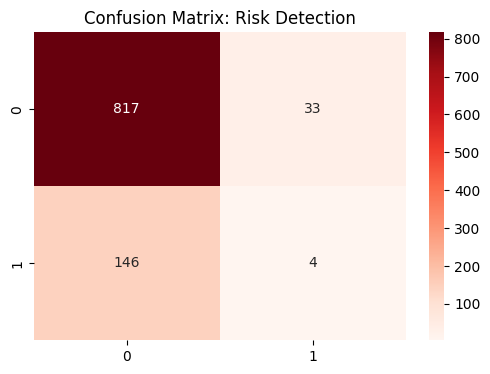

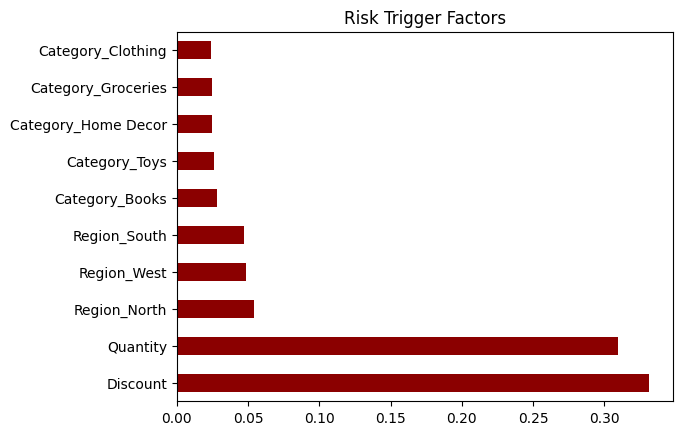

In [5]:
y_pred = rf_model.predict(X_test)

print("--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Risk Detection')
plt.show()

# Fitur Paling Berpengaruh
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
importances.nlargest(10).plot(kind='barh', color='darkred')
plt.title('Risk Trigger Factors')
plt.show()

# Save Model

Açıklama: Başarıyla eğitilen model, daha sonra Streamlit veya diğer uygulamalarda kullanılmak üzere .pkl formatında kaydedilir. Bu işlem, her seferinde modeli tekrar eğitme zorunluluğunu ortadan kaldırır.

In [6]:
joblib.dump(rf_model, 'model_risiko_cerdas.pkl')
# Menyimpan urutan kolom sangat penting agar aplikasi UI tidak error nantinya
joblib.dump(X_encoded.columns.tolist(), 'X_columns.pkl')
print("Model dan daftar kolom berhasil disimpan!")

Model dan daftar kolom berhasil disimpan!
